# Loading the dataset

In [1]:


import os
import numpy as np
from PIL import Image

# Path to the dataset created by DatasetFolder.py
DS_PATH = './IndustryBiscuit_Folders'


LABEL_MAP = {'ok': 0, 'nok': 1}


IMG_SIZE = (128, 128)


GRAYSCALE = False

In [2]:
def _load_split(ds_path, split, img_size=IMG_SIZE, grayscale=GRAYSCALE):
    """
    Load a single split ('train', 'valid', or 'test') from disk.

    Returns
    -------
    X : np.ndarray, shape (n_samples, H, W) or (n_samples, H, W, 3)
    y : np.ndarray, shape (n_samples,)   0 = ok, 1 = nok
    filenames : list[str]                original file names, same order as X/y
    """
    images = []
    labels = []
    filenames = []

    split_path = os.path.join(ds_path, split)

    for folder_name, label in LABEL_MAP.items():
        class_path = os.path.join(split_path, folder_name)

        if not os.path.isdir(class_path):
            raise FileNotFoundError(
                f"Expected folder not found: {class_path}. "
                f"Did you run DatasetFolder.py first?"
            )

        for fname in sorted(os.listdir(class_path)):
            fpath = os.path.join(class_path, fname)

            if not os.path.isfile(fpath):
                continue

            with Image.open(fpath) as im:
                if grayscale:
                    im = im.convert('L')
                else:
                    im = im.convert('RGB')

                im = im.resize(img_size)
                images.append(np.asarray(im, dtype=np.uint8))

            labels.append(label)
            filenames.append(fname)

    X = np.stack(images, axis=0)
    y = np.array(labels, dtype=np.int64)

    return X, y, filenames

In [3]:
def load_dataset(ds_path=DS_PATH, img_size=IMG_SIZE, grayscale=GRAYSCALE):
    """
    Load train, valid and test splits.

    Returns
    -------
    dict with keys 'train', 'valid', 'test', each mapping to (X, y, filenames)
    """
    dataset = {}
    for split in ('train', 'valid', 'test'):
        dataset[split] = _load_split(ds_path, split, img_size, grayscale)
    return dataset

In [13]:

data = load_dataset()

for split in ('train', 'valid', 'test'):
    X, y, filenames = data[split]
    n_ok = int(np.sum(y == 0))
    n_nok = int(np.sum(y == 1))
    print(f"{split:5s} -> X: {X.shape}, ok: {n_ok}, nok: {n_nok}")

train -> X: (2600, 128, 128, 3), ok: 1300, nok: 1300
valid -> X: (558, 128, 128, 3), ok: 280, nok: 278
test  -> X: (600, 128, 128, 3), ok: 300, nok: 300


# Feature Extraction

## HOG(Histogram of Oriented Gradients) :
https://youtu.be/28xk5i1_7Zc?si=5CPdBH574aWcEtEJ
## LBP(Local Binary Patterns) : 
https://youtu.be/wpAwdsubl1w?si=faA-NmPUfwziXsla


In [5]:

"""
Combines three complementary feature types:
    - HOG   (Histogram of Oriented Gradients) -> captures shape/edges
    - LBP   (Local Binary Patterns)            -> captures texture
    - Color histogram (per HSV channel)        -> captures color

"""

import numpy as np
from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import hog, local_binary_pattern

# ---- HOG parameters ----
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS = 9

# ---- LBP parameters ----
LBP_RADIUS = 3
LBP_N_POINTS = 8 * LBP_RADIUS  # 24
LBP_METHOD = 'uniform'
LBP_N_BINS = LBP_N_POINTS + 2  # 'uniform' LBP produces n_points + 2 distinct values

# ---- Color histogram parameters ----
COLOR_BINS_PER_CHANNEL = 32


def _hog_single(gray_img):
    return hog(
        gray_img,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        feature_vector=True,
    )


def _lbp_single(gray_img):
    lbp = local_binary_pattern(gray_img, LBP_N_POINTS, LBP_RADIUS, method=LBP_METHOD)
    hist, _ = np.histogram(
        lbp, bins=LBP_N_BINS, range=(0, LBP_N_BINS), density=True
    )
    return hist


def _color_hist_single(rgb_img):
    hsv_img = rgb2hsv(rgb_img)
    hists = []
    for ch in range(3):  # H, S, V
        hist, _ = np.histogram(
            hsv_img[:, :, ch], bins=COLOR_BINS_PER_CHANNEL, range=(0, 1), density=True
        )
        hists.append(hist)
    return np.concatenate(hists)


def extract_features(images, use_hog=True, use_lbp=True, use_color=True, verbose=True):
    """
    Parameters
    ----------
    images : np.ndarray, shape (N, H, W, 3), dtype uint8
        Output of load_data.load_dataset()['split'][0]
    use_hog, use_lbp, use_color : bool
        Toggle each feature family on/off.
    verbose : bool
        Print progress every 500 images.

    Returns
    -------
    X : np.ndarray, shape (N, n_features)
    """
    n = images.shape[0]
    feature_rows = []

    for i in range(n):
        img = images[i]
        img_float = img.astype(np.float64) / 255.0
        gray = rgb2gray(img_float)

        parts = []
        if use_hog:
            parts.append(_hog_single(gray))
        if use_lbp:
            parts.append(_lbp_single(gray))
        if use_color:
            parts.append(_color_hist_single(img_float))

        feature_rows.append(np.concatenate(parts))

        if verbose and (i + 1) % 500 == 0:
            print(f"  extracted {i + 1}/{n}")

    X = np.stack(feature_rows, axis=0)
    return X

In [6]:
data = load_dataset()
X_train_img, y_train, _ = data['train']
X_valid_img, y_valid, _ = data['valid']
X_test_img,  y_test,  _ = data['test']

X_train = extract_features(X_train_img)
X_valid = extract_features(X_valid_img)
X_test  = extract_features(X_test_img)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


  extracted 500/2600
  extracted 1000/2600
  extracted 1500/2600
  extracted 2000/2600
  extracted 2500/2600
  extracted 500/558
  extracted 500/600


In [14]:
print(X_train_img.shape , X_valid_img.shape , X_test_img.shape)
print(X_train.shape , X_valid.shape , X_test.shape)

(2600, 128, 128, 3) (558, 128, 128, 3) (600, 128, 128, 3)
(2600, 1886) (558, 1886) (600, 1886)


## - Feature Scaling
## - Train and Evaluate
## - Evaluate on Test

In [10]:

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)


def scale_features(X_train, X_valid, X_test):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_valid_s = scaler.transform(X_valid)
    X_test_s = scaler.transform(X_test)
    return X_train_s, X_valid_s, X_test_s, scaler


MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'SVM_RBF': SVC(kernel='rbf', class_weight='balanced'),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42
    ),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
}


def train_and_evaluate(models, X_train, y_train, X_valid, y_valid, verbose=True):
    """
    Trains each model in `models` on (X_train, y_train) and evaluates on
    (X_valid, y_valid).

    Returns
    -------
    dict: {model_name: {'model': fitted_estimator,
                         'accuracy': float,
                         'report': str,
                         'confusion_matrix': np.ndarray}}
    """
    results = {}

    for name, model in models.items():
        if verbose:
            print(f"Training {name}...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_valid)

        acc = accuracy_score(y_valid, y_pred)
        report = classification_report(y_valid, y_pred, target_names=['ok', 'nok'])
        cm = confusion_matrix(y_valid, y_pred)

        results[name] = {
            'model': model,
            'accuracy': acc,
            'report': report,
            'confusion_matrix': cm,
        }

        if verbose:
            print(f"  {name} validation accuracy: {acc:.4f}")
            print(report)
            print(f"  confusion matrix:\n{cm}\n")

    return results


def evaluate_on_test(model, X_test, y_test):
    """
    Final, single evaluation on the held-out test set for the model you
    selected based on validation performance.
    """
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['ok', 'nok'])
    cm = confusion_matrix(y_test, y_pred)

    print(f"Test accuracy: {acc:.4f}")
    print(report)
    print(f"confusion matrix:\n{cm}")

    return {'accuracy': acc, 'report': report, 'confusion_matrix': cm}

# Visualiziation and Evaluation

In [34]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


CLASS_NAMES = ['ok', 'nok']


def plot_class_distribution(y_train, y_valid, y_test):
    """Bar chart of ok/nok counts per split — quick sanity check for balance."""
    splits = ['train', 'valid', 'test']
    ys = [y_train, y_valid, y_test]

    ok_counts = [int(np.sum(y == 0)) for y in ys]
    nok_counts = [int(np.sum(y == 1)) for y in ys]

    x = np.arange(len(splits))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width / 2, ok_counts, width, label='ok')
    ax.bar(x + width / 2, nok_counts, width, label='nok')

    for i, (ok_c, nok_c) in enumerate(zip(ok_counts, nok_counts)):
        ax.text(i - width / 2, ok_c + 5, str(ok_c), ha='center', fontsize=9)
        ax.text(i + width / 2, nok_c + 5, str(nok_c), ha='center', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel('Number of images')
    ax.set_title('Class distribution per split')
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_sample_images(images, y, n_per_class=4):
    ok_idx = np.where(y == 0)[0]
    nok_idx = np.where(y == 1)[0]

    rng = np.random.default_rng(42)
    ok_sample = rng.choice(ok_idx, size=min(n_per_class, len(ok_idx)), replace=False)
    nok_sample = rng.choice(nok_idx, size=min(n_per_class, len(nok_idx)), replace=False)

    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6))

    for col, idx in enumerate(ok_sample):
        axes[0, col].imshow(images[idx])
        axes[0, col].set_title('ok')
        axes[0, col].axis('off')

    for col, idx in enumerate(nok_sample):
        axes[1, col].imshow(images[idx])
        axes[1, col].set_title('nok')
        axes[1, col].axis('off')

    fig.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 2. Model evaluation
# ---------------------------------------------------------------------------

def plot_confusion_matrix(cm, title='Confusion matrix', ax=None):
    """Plot a single confusion matrix as an annotated heatmap."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4, 4))

    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > thresh else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color)

    if own_fig:
        fig.tight_layout()
        plt.show()


def plot_all_confusion_matrices(results):
    names = list(results.keys())
    n = len(names)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, name in enumerate(names):
        cm = results[name]['confusion_matrix']
        acc = results[name]['accuracy']
        plot_confusion_matrix(cm, title=f'{name}\nacc={acc:.3f}', ax=axes[i])

    for j in range(len(names), len(axes)):
        axes[j].axis('off')

    fig.tight_layout()
    plt.show()


def plot_accuracy_comparison(results):
    """Bar chart comparing validation accuracy across models."""
    names = list(results.keys())
    accs = [results[name]['accuracy'] for name in names]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(names, accs, color='steelblue')
    ax.set_ylabel('Validation accuracy')
    ax.set_ylim(0, 1)
    ax.set_title('Model comparison (validation set)')
    plt.xticks(rotation=20, ha='right')

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f'{acc:.3f}',
                 ha='center', fontsize=9)

    fig.tight_layout()
    plt.show()


def _get_scores(model, X):
    """Returns a 1D array of scores usable for an ROC curve, regardless of
    whether the model exposes predict_proba or only decision_function."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        return model.decision_function(X)
    else:
        raise ValueError(
            f"{type(model).__name__} has neither predict_proba nor "
            f"decision_function — can't compute ROC."
        )


def plot_roc_curves(results, X_valid, y_valid):

    fig, ax = plt.subplots(figsize=(6, 6))

    for name, res in results.items():
        model = res['model']
        try:
            scores = _get_scores(model, X_valid)
        except ValueError as e:
            print(f"Skipping {name}: {e}")
            continue

        fpr, tpr, _ = roc_curve(y_valid, scores)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title('ROC curves (validation set)')
    ax.legend(loc='lower right', fontsize=8)
    fig.tight_layout()
    plt.show()


def plot_feature_importance(model, top_n=20):
    """Feature importance for tree-based models (RandomForest, GradientBoosting).
    Features are indices into the concatenated [HOG | LBP | color] vector —
    not individually named, since HOG/LBP don't map to single interpretable
    pixels — but this still shows which region of the feature vector (and
    therefore which feature family) the model relies on most.
    """
    if not hasattr(model, 'feature_importances_'):
        raise ValueError(
            f"{type(model).__name__} has no feature_importances_ "
            f"(only tree-based models like RandomForest/GradientBoosting do)."
        )

    importances = model.feature_importances_
    top_idx = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(range(top_n), importances[top_idx], color='seagreen')
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(top_idx, rotation=90)
    ax.set_xlabel('Feature index (in concatenated HOG|LBP|color vector)')
    ax.set_ylabel('Importance')
    ax.set_title(f'Top {top_n} feature importances — {type(model).__name__}')
    fig.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 3. Making feature importance interpretable
#    (mapping a raw index back to a feature FAMILY, and for HOG, an
#    image REGION — this is what actually answers "which feature matters")
# ---------------------------------------------------------------------------

def compute_feature_boundaries(
    img_size=(128, 128),
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    orientations=9,
    lbp_n_bins=26,
    color_bins_per_channel=32,
    use_hog=True,
    use_lbp=True,
    use_color=True,
):

    boundaries = {}
    cursor = 0

    if use_hog:
        n_cells_row = img_size[0] // pixels_per_cell[0]
        n_cells_col = img_size[1] // pixels_per_cell[1]
        n_blocks_row = n_cells_row - cells_per_block[0] + 1
        n_blocks_col = n_cells_col - cells_per_block[1] + 1
        hog_len = (n_blocks_row * n_blocks_col *
                   cells_per_block[0] * cells_per_block[1] * orientations)

        boundaries['hog'] = {
            'start': cursor,
            'end': cursor + hog_len,
            'block_shape': (n_blocks_row, n_blocks_col,
                             cells_per_block[0], cells_per_block[1], orientations),
            'n_blocks_row': n_blocks_row,
            'n_blocks_col': n_blocks_col,
            'pixels_per_cell': pixels_per_cell,
        }
        cursor += hog_len

    if use_lbp:
        boundaries['lbp'] = {'start': cursor, 'end': cursor + lbp_n_bins}
        cursor += lbp_n_bins

    if use_color:
        ch_names = ['H', 'S', 'V']
        channels = {}
        for ch in ch_names:
            channels[ch] = {'start': cursor, 'end': cursor + color_bins_per_channel}
            cursor += color_bins_per_channel
        boundaries['color'] = {
            'start': cursor - 3 * color_bins_per_channel,
            'end': cursor,
            'channels': channels,
        }

    return boundaries


def plot_feature_importance_by_family(model, boundaries):
    """
    Sums feature_importances_ within each family's index range, so instead
    of '#412 is important' you get 'HOG is 61% of total importance, color
    is 30%, LBP is 9%' — directly answers which TYPE of feature matters.
    Also breaks the color family down by H/S/V channel.
    """
    if not hasattr(model, 'feature_importances_'):
        raise ValueError(
            f"{type(model).__name__} has no feature_importances_ "
            f"(only tree-based models like RandomForest/GradientBoosting do)."
        )
    importances = model.feature_importances_

    family_totals = {}
    for family in ('hog', 'lbp', 'color'):
        if family in boundaries:
            s, e = boundaries[family]['start'], boundaries[family]['end']
            family_totals[family.upper()] = importances[s:e].sum()

    fig, axes = plt.subplots(1, 2 if 'color' in boundaries else 1, figsize=(11, 4))
    if 'color' not in boundaries:
        axes = [axes]

    names = list(family_totals.keys())
    totals = list(family_totals.values())
    axes[0].bar(names, totals, color=['tab:blue', 'tab:orange', 'tab:green'][:len(names)])
    axes[0].set_ylabel('Summed importance')
    axes[0].set_title('Importance by feature family')
    for i, v in enumerate(totals):
        axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

    if 'color' in boundaries:
        ch_totals = {}
        for ch, rng in boundaries['color']['channels'].items():
            ch_totals[ch] = importances[rng['start']:rng['end']].sum()
        axes[1].bar(list(ch_totals.keys()), list(ch_totals.values()), color='seagreen')
        axes[1].set_ylabel('Summed importance')
        axes[1].set_title('Color family, by HSV channel')

    fig.tight_layout()
    plt.show()

    return family_totals


def plot_hog_block_importance(model, boundaries, sample_image=None):
    """
    The most useful one for a visual defect task: reshapes the HOG portion
    of feature_importances_ back into its spatial block grid, so you get a
    heatmap of WHICH REGION of the image the model actually relies on
    (e.g. does it look at the biscuit edges for Defect_Shape, or the whole
    surface for Defect_Object/texture issues?).

    Pass a sample_image (H, W, 3) to overlay the heatmap on top of an actual
    biscuit for context — otherwise it's shown on its own.
    """
    if 'hog' not in boundaries:
        raise ValueError("No 'hog' entry in boundaries — was use_hog=True?")
    if not hasattr(model, 'feature_importances_'):
        raise ValueError(
            f"{type(model).__name__} has no feature_importances_ "
            f"(only tree-based models like RandomForest/GradientBoosting do)."
        )

    hb = boundaries['hog']
    hog_importances = model.feature_importances_[hb['start']:hb['end']]
    block_grid = hog_importances.reshape(hb['block_shape'])

    # sum over the 2x2 cells-per-block and 9 orientation bins -> one value per block
    block_map = block_grid.sum(axis=(2, 3, 4))  # shape (n_blocks_row, n_blocks_col)

    fig, ax = plt.subplots(figsize=(5, 5))

    if sample_image is not None:
        ax.imshow(sample_image)
        extent = (0, sample_image.shape[1], sample_image.shape[0], 0)
        ax.imshow(block_map, cmap='hot', alpha=0.5, extent=extent, interpolation='bilinear')
    else:
        im = ax.imshow(block_map, cmap='hot', interpolation='nearest')
        fig.colorbar(im, ax=ax)

    ax.set_title('HOG block importance — where the model looks')
    ax.axis('off')
    fig.tight_layout()
    plt.show()

    return block_map

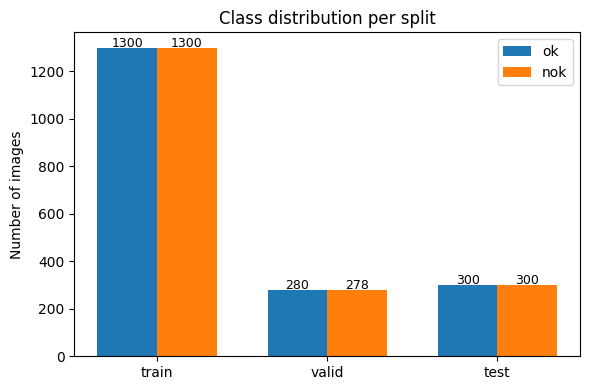

In [35]:
plot_class_distribution(y_train, y_valid, y_test)

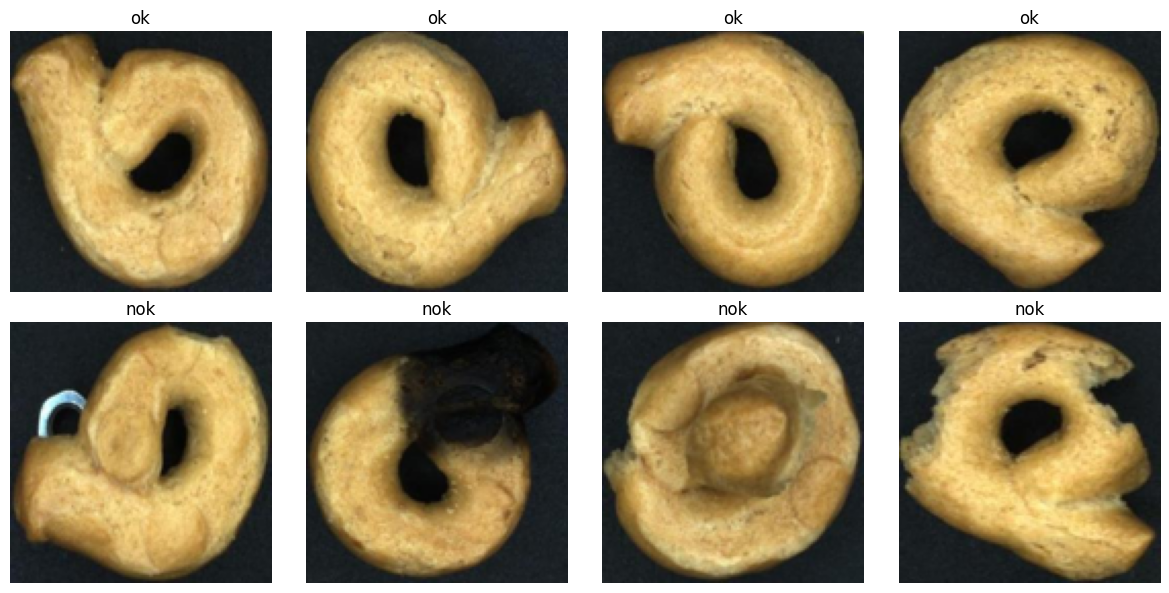

In [36]:
plot_sample_images(X_train_img, y_train)   # note: pass the raw image arrays, not features

In [14]:
X_train_s, X_valid_s, X_test_s, scaler = scale_features(X_train, X_valid, X_test)

results = train_and_evaluate(MODELS, X_train_s, y_train, X_valid_s, y_valid)

Training LogisticRegression...
  LogisticRegression validation accuracy: 0.9176
              precision    recall  f1-score   support

          ok       0.95      0.88      0.91       280
         nok       0.89      0.95      0.92       278

    accuracy                           0.92       558
   macro avg       0.92      0.92      0.92       558
weighted avg       0.92      0.92      0.92       558

  confusion matrix:
[[247  33]
 [ 13 265]]

Training kNN...
  kNN validation accuracy: 0.8208
              precision    recall  f1-score   support

          ok       0.74      1.00      0.85       280
         nok       1.00      0.64      0.78       278

    accuracy                           0.82       558
   macro avg       0.87      0.82      0.81       558
weighted avg       0.87      0.82      0.81       558

  confusion matrix:
[[280   0]
 [100 178]]

Training SVM_RBF...
  SVM_RBF validation accuracy: 0.9767
              precision    recall  f1-score   support

          ok   

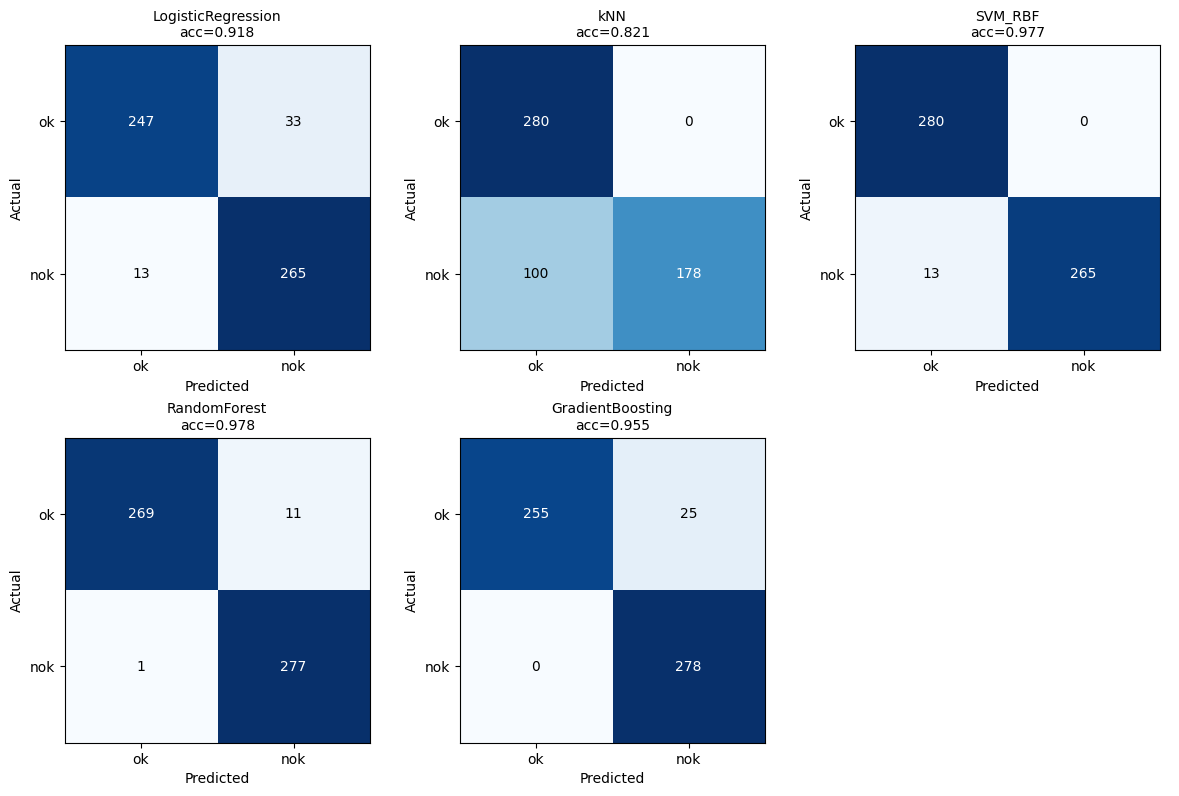

In [37]:
plot_all_confusion_matrices(results)          

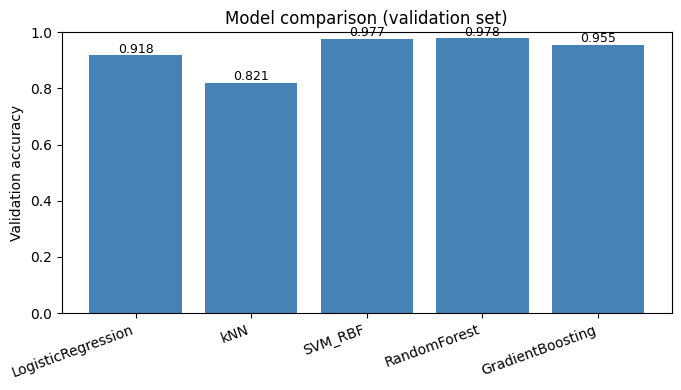

In [38]:
plot_accuracy_comparison(results)            

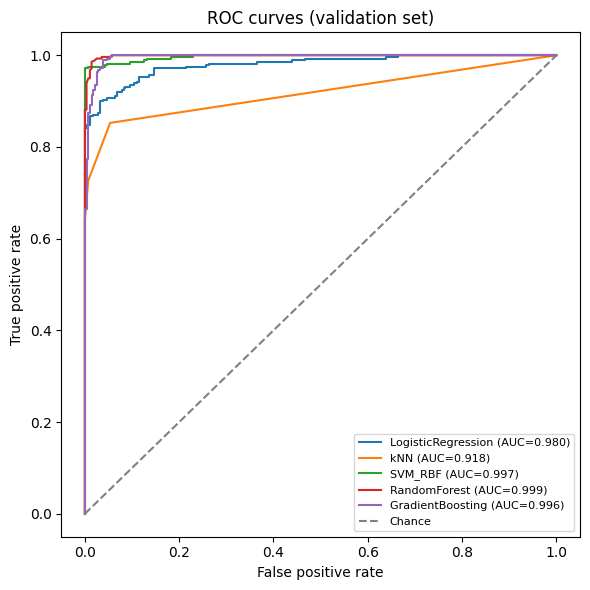

In [39]:
plot_roc_curves(results, X_valid_s, y_valid)  # ROC + AUC, all models on one plot

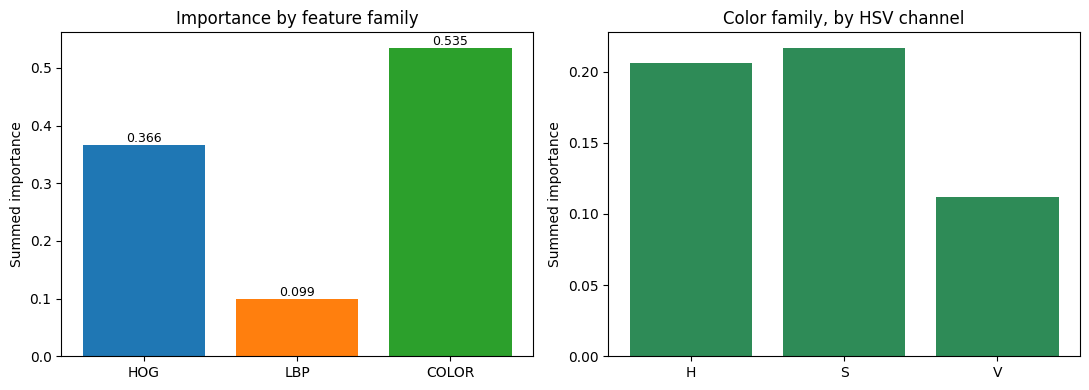

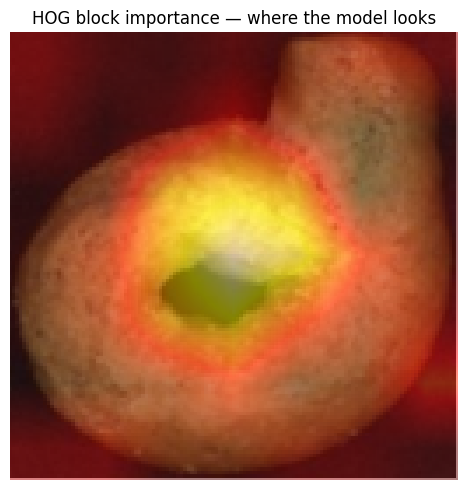

array([[0.00757128, 0.00691795, 0.00672002, 0.00718008, 0.00666576,
        0.00727871, 0.00728759],
       [0.0072371 , 0.00653508, 0.00708518, 0.00819456, 0.00690501,
        0.00601   , 0.00637396],
       [0.00639376, 0.00666842, 0.00952768, 0.00987124, 0.00937152,
        0.00596565, 0.0066581 ],
       [0.00649827, 0.00738788, 0.00966983, 0.01146085, 0.01058402,
        0.0080027 , 0.00673986],
       [0.00637417, 0.00711737, 0.00932793, 0.01003539, 0.00823315,
        0.00701255, 0.00733437],
       [0.00620851, 0.00643118, 0.00684973, 0.00777281, 0.0063863 ,
        0.0065685 , 0.00839156],
       [0.00734948, 0.00745671, 0.00661822, 0.00658266, 0.00712587,
        0.00710204, 0.00673558]])

In [40]:
boundaries = compute_feature_boundaries() 

plot_feature_importance_by_family(results['RandomForest']['model'], boundaries)
plot_hog_block_importance(results['RandomForest']['model'], boundaries,
                           sample_image=X_train_img[0])